In [1]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()

zip_file = list(uploaded.keys())[0]

extract_path = "/content/NADI2021_DEV"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted to:", extract_path)

print(os.listdir(extract_path))

Saving NADI2021_DEV.1.0.zip to NADI2021_DEV.1.0.zip
Files extracted to: /content/NADI2021_DEV
['NADI2021_DEV.1.0']


In [6]:
base_path = "/content/NADI2021_DEV"

for root, dirs, files in os.walk(base_path):
    print("ROOT:", root)
    print("FILES:", files)
    print("-" * 50)

ROOT: /content/NADI2021_DEV
FILES: []
--------------------------------------------------
ROOT: /content/NADI2021_DEV/NADI2021_DEV.1.0
FILES: ['NADI2021-unlabeled_10M.tsv', 'NADI2021-Twitter-Corpus-License.txt', 'NADI2021-DID-Scorer.py', 'NADI2021-README.txt', 'NADI2021-Obtain-Tweets.py']
--------------------------------------------------
ROOT: /content/NADI2021_DEV/NADI2021_DEV.1.0/Subtask_1.2+2.2_DA
FILES: ['subtask12_GOLD.txt', 'subtask22_GOLD.txt', 'DA_train_labeled.tsv', 'DA_dev_labeled.tsv', 'UBC_subtask12_dev_1.zip', 'UBC_subtask22_dev_1.zip']
--------------------------------------------------
ROOT: /content/NADI2021_DEV/NADI2021_DEV.1.0/Subtask_1.1+2.1_MSA
FILES: ['UBC_subtask21_dev_1.zip', 'MSA_train_labeled.tsv', 'UBC_subtask11_dev_1.zip', 'MSA_dev_labeled.tsv', 'subtask11_GOLD.txt', 'subtask21_GOLD.txt']
--------------------------------------------------


In [7]:
#lets prefume some data exploration steps

In [8]:
import pandas as pd

train_path = "/content/NADI2021_DEV/NADI2021_DEV.1.0/Subtask_1.2+2.2_DA/DA_train_labeled.tsv"

df = pd.read_csv(train_path, sep="\t")

df.head()

,#1_tweetid,#2_tweet,#3_country_label,#4_province_label
0,TRAIN_0,حاجة حلوة اكيد,Egypt,eg_Faiyum
1,TRAIN_1,عم بشتغلوا للشعب الاميركي اما نحن يكذبوا ويغشو...,Iraq,iq_Dihok
2,TRAIN_2,ابشر طال عمرك,Saudi_Arabia,sa_Ha'il
3,TRAIN_3,منطق 2017: أنا والغريب علي إبن عمي وأنا والغري...,Mauritania,mr_Nouakchott
4,TRAIN_4,شهرين وتروح والباقي غير صيف ملينا,Algeria,dz_El-Oued


In [9]:
df.shape

(21000, 4)

In [10]:
df.columns

Index(['#1_tweetid', '#2_tweet', '#3_country_label', '#4_province_label'], dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   #1_tweetid         21000 non-null  object
 1   #2_tweet           21000 non-null  object
 2   #3_country_label   21000 non-null  object
 3   #4_province_label  21000 non-null  object
dtypes: object(4)
memory usage: 656.4+ KB


In [12]:
df.isnull().sum()

,0
#1_tweetid,0
#2_tweet,0
#3_country_label,0
#4_province_label,0


In [13]:
df.sample(5)

,#1_tweetid,#2_tweet,#3_country_label,#4_province_label
7380,TRAIN_7380,لو صرفتوا راتب لربات البيوت المخلصات عشان ما ن...,Morocco,ma_Souss-Massa-Draa
12658,TRAIN_12658,ايه ياعم الامراض النفسيه,Egypt,eg_Red-Sea
10946,TRAIN_10946,خريجة لحد يكلمها,Oman,om_Musandam
3152,TRAIN_3152,احبببك دايماً تقولي الي ابغا اقوله,Saudi_Arabia,sa_Ar-Riyad
8284,TRAIN_8284,قوليلى ميزة وحدة فيه عن باقى البنوك,Egypt,eg_Asyut


In [14]:
label_col = df.columns[-1]

df[label_col].value_counts()

,count
#4_province_label,
iq_Dihok,215
mr_Nouakchott,215
lb_North-Lebanon,215
dz_El-Oued,215
dz_Biskra,215
...,...
ly_Al-Butnan,214
iq_As-Sulaymaniyah,153
so_Banaadir,136


<Axes: xlabel='#4_province_label'>

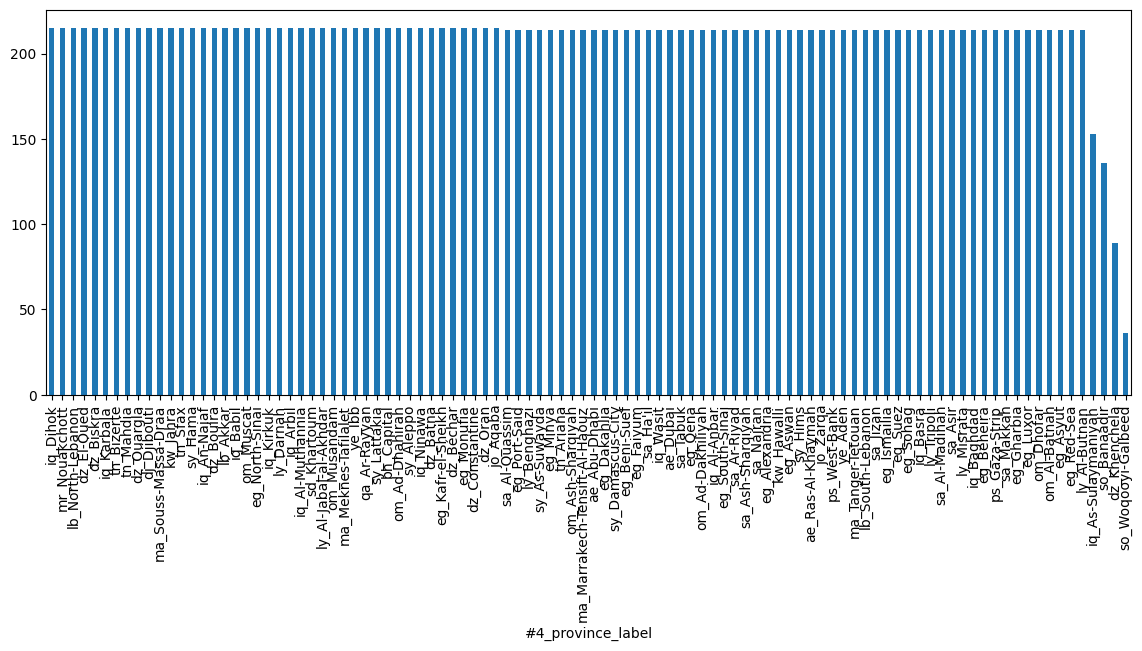

In [15]:
df[label_col].value_counts().plot(kind="bar", figsize=(14,5))

In [16]:
text_col = df.columns[0]

df["text_length"] = df[text_col].astype(str).apply(len)

df["text_length"].describe()

,text_length
count,21000.000000
mean,10.470952
std,0.605241
min,7.000000
25%,10.000000
50%,11.000000
75%,11.000000
max,11.000000


In [24]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:10])
    print("-" * 50)

#1_tweetid
['TRAIN_0' 'TRAIN_1' 'TRAIN_2' 'TRAIN_3' 'TRAIN_4' 'TRAIN_5' 'TRAIN_6'
 'TRAIN_7' 'TRAIN_8' 'TRAIN_9']
--------------------------------------------------
#2_tweet
['حاجة حلوة اكيد'
 'عم بشتغلوا للشعب الاميركي اما نحن يكذبوا ويغشوا ويسرقوا ويقتلو شعوبهم ويعملوا لصالح اعدائهم'
 'ابشر طال عمرك'
 'منطق 2017: أنا والغريب علي إبن عمي وأنا والغريب وإبن عمي علي أخويا. #قطع_العلاقات_مع_قطر #موريتانيا_مع_قطر'
 'شهرين وتروح والباقي غير صيف ملينا'
 'يابنتى والله ما حد متغاظ ولا مفروس منك ولا بيحسدك انتى عره اساسا.'
 'نفس الوقت بأكد على صاحبتي ان اي هدف هتحطه وتخططله هيبوظ والأفضل التشاؤم واننا نتوقع الأسوء دايما والفشل عشان منعشمش نفسنا ع الفاضي'
 'م تبطلي خرا بقا علشان مطلعهوش عليكي احترمي نفسك URL \xa0…'
 'ما يله دخل !' 'هو حلو بس يتخربط ع طلاب المدراس ليك مايغيرونه عدنا']
--------------------------------------------------
#3_country_label
['Egypt' 'Iraq' 'Saudi_Arabia' 'Mauritania' 'Algeria' 'Syria' 'Oman'
 'Tunisia' 'Lebanon' 'Morocco']
----------------------------------------------

In [25]:
country_col = df.columns[1]

country_counts = df[country_col].value_counts().reset_index()

country_counts.columns = ["Country", "Samples"]

print(country_counts)

                                                 Country  Samples
0                              اطلقي يد الراجل حرام عليك        3
1                                         ربي يجيب الخير        3
2                                      يسعد مساكي بالخير        3
3                                           كلن يعني كلن        2
4              المخرج مطلوب حيا أو ميتا هههههههههه  URL         2
...                                                  ...      ...
20968                  فكرت حدن من الشلة علمك تراهم خبرة        1
20969                    حرام ما فهم شو يعني تقدمت مهنئة        1
20970  ليه بنحس اننا مرينا بنفس الموقف دا قبل كدا بنف...        1
20971                     USER   USER  ما يامر عليك ضالم        1
20972                          لك جنت دا ارد ع هذا  URL         1

[20973 rows x 2 columns]


In [27]:
country_counts = df['#3_country_label'].value_counts().reset_index()

country_counts.columns = ['Country', 'Samples']

print(country_counts)

                 Country  Samples
0                  Egypt     4283
1                   Iraq     2729
2           Saudi_Arabia     2140
3                Algeria     1809
4                   Oman     1501
5                  Syria     1287
6                  Libya     1286
7                Tunisia      859
8                Morocco      858
9                Lebanon      644
10  United_Arab_Emirates      642
11                Jordan      429
12                Kuwait      429
13                 Yemen      429
14             Palestine      428
15            Mauritania      215
16              Djibouti      215
17                 Qatar      215
18               Bahrain      215
19                 Sudan      215
20               Somalia      172


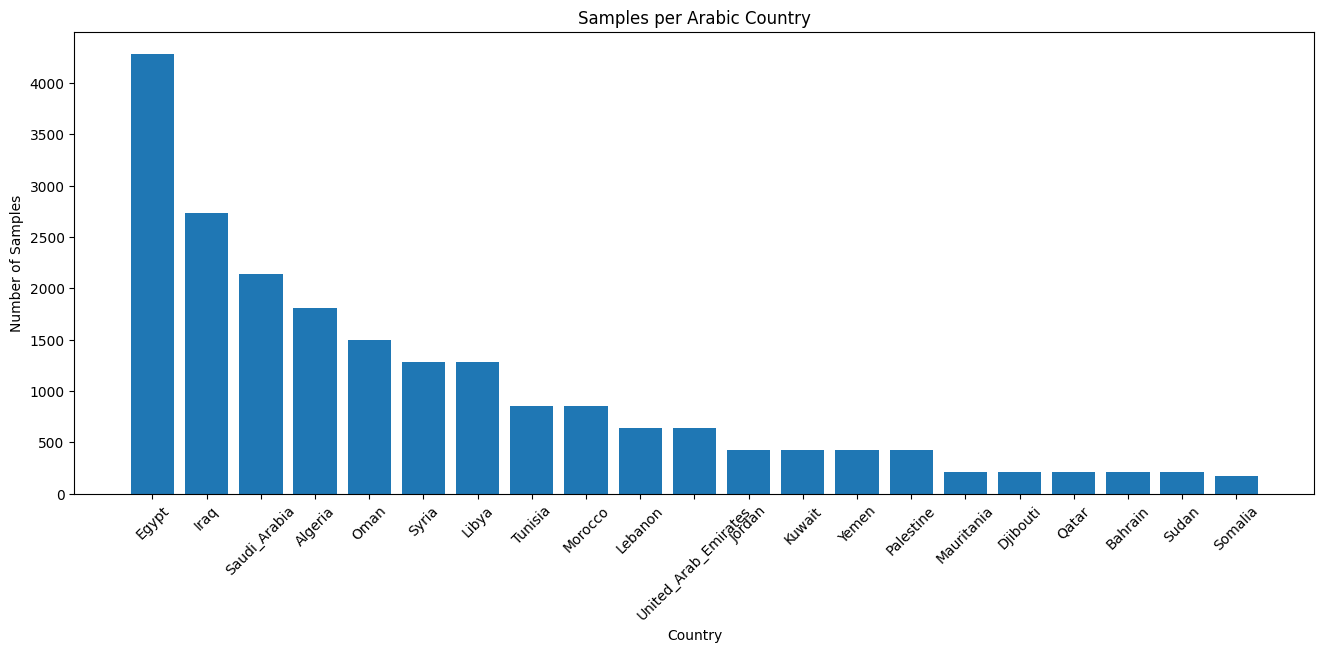

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))

plt.bar(country_counts['Country'], country_counts['Samples'])

plt.xticks(rotation=45)

plt.xlabel('Country')
plt.ylabel('Number of Samples')
plt.title('Samples per Arabic Country')

plt.show()

In [30]:
#as we can see the data is unbalanced let's make it balanced (preprocessing)
from sklearn.utils import resample
import pandas as pd

country_col = '#3_country_label'

max_samples = df[country_col].value_counts().max()

balanced_df = pd.DataFrame()

for country in df[country_col].unique():

    country_df = df[df[country_col] == country]

    upsampled_df = resample(
        country_df,
        replace=True,
        n_samples=max_samples,
        random_state=42
    )

    balanced_df = pd.concat([balanced_df, upsampled_df])

balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

balanced_df[country_col].value_counts()

,count
#3_country_label,
Egypt,4283
Somalia,4283
United_Arab_Emirates,4283
Libya,4283
Kuwait,4283
Djibouti,4283
Qatar,4283
Syria,4283
Morocco,4283


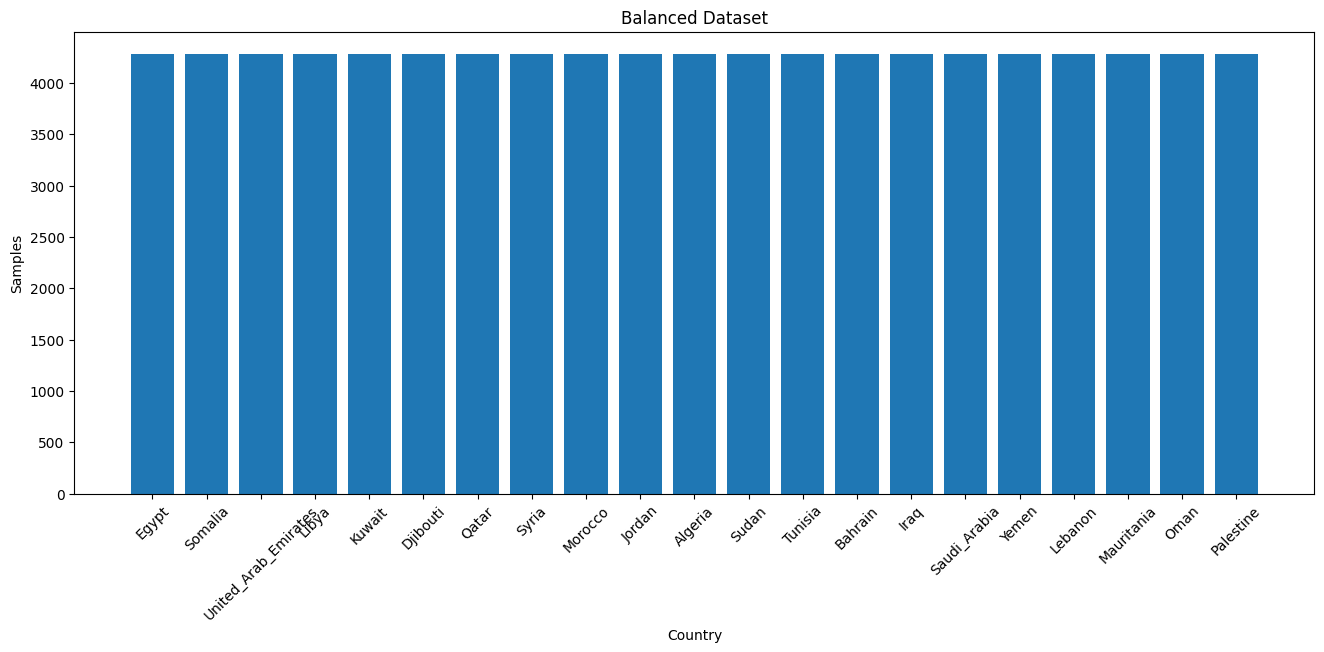

In [31]:
#as we can see now it's much better
balanced_counts = balanced_df[country_col].value_counts()

plt.figure(figsize=(16,6))

plt.bar(balanced_counts.index, balanced_counts.values)

plt.xticks(rotation=45)

plt.xlabel("Country")
plt.ylabel("Samples")
plt.title("Balanced Dataset")

plt.show()

In [32]:
#let's make them grouped
region_mapping = {
    "Morocco": "North_Africa",
    "Algeria": "North_Africa",
    "Tunisia": "North_Africa",
    "Libya": "North_Africa",
    "Mauritania": "North_Africa",

    "Egypt": "Nile_Valley",
    "Sudan": "Nile_Valley",
    "Somalia": "Horn_of_Africa",
    "Djibouti": "Horn_of_Africa",

    "Saudi_Arabia": "Gulf",
    "United_Arab_Emirates": "Gulf",
    "Kuwait": "Gulf",
    "Qatar": "Gulf",
    "Bahrain": "Gulf",
    "Oman": "Gulf",
    "Yemen": "Gulf",
    "Iraq": "Gulf",

    "Syria": "Levant",
    "Lebanon": "Levant",
    "Jordan": "Levant",
    "Palestine": "Levant"
}

balanced_df["Region"] = balanced_df["#3_country_label"].map(region_mapping)

balanced_df[["#3_country_label", "Region"]].head()

,#3_country_label,Region
0,Egypt,Nile_Valley
1,Somalia,Horn_of_Africa
2,United_Arab_Emirates,Gulf
3,Libya,North_Africa
4,Kuwait,Gulf


In [33]:
region_counts = balanced_df["Region"].value_counts().reset_index()

region_counts.columns = ["Region", "Samples"]

print(region_counts)

           Region  Samples
0            Gulf    34264
1    North_Africa    21415
2          Levant    17132
3     Nile_Valley     8566
4  Horn_of_Africa     8566


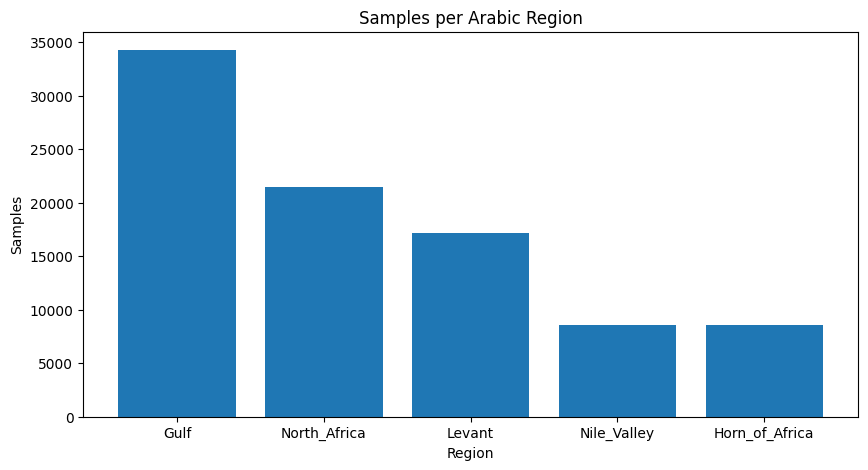

In [34]:
plt.figure(figsize=(10,5))

plt.bar(region_counts["Region"], region_counts["Samples"])

plt.xlabel("Region")
plt.ylabel("Samples")
plt.title("Samples per Arabic Region")

plt.show()

In [35]:
!pip install transformers datasets sentencepiece -q

In [36]:
from sklearn.preprocessing import LabelEncoder

text_col = '#2_tweet'
label_col = 'Region'

le = LabelEncoder()

balanced_df['label'] = le.fit_transform(balanced_df[label_col])

num_labels = balanced_df['label'].nunique()

print(le.classes_)
print(num_labels)

['Gulf' 'Horn_of_Africa' 'Levant' 'Nile_Valley' 'North_Africa']
5


In [37]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    balanced_df[text_col].tolist(),
    balanced_df['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=balanced_df['label']
)

In [38]:
from transformers import AutoTokenizer

model_name = "UBC-NLP/MARBERT"

tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.10M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [39]:
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    val_texts,
    truncation=True,
    padding=True,
    max_length=128
)

In [40]:
import torch

class NadiDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [41]:
train_dataset = NadiDataset(train_encodings, train_labels)
val_dataset = NadiDataset(val_encodings, val_labels)

In [42]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

pytorch_model.bin:   0%|          | 0.00/654M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider

In [43]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=100
)

In [44]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="weighted")
    }

In [45]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [46]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.316281,0.267591,0.946301,0.946033
2,0.054429,0.162200,0.975652,0.975615
3,0.012431,0.133517,0.980710,0.980696


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=26985, training_loss=0.22825512255212213, metrics={'train_runtime': 5964.3936, 'train_samples_per_second': 36.192, 'train_steps_per_second': 4.524, 'total_flos': 1.4199302117140992e+16, 'train_loss': 0.22825512255212213, 'epoch': 3.0})

In [47]:
trainer.evaluate()

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.012431,0.133517,3,0.980710,0.980696


{'eval_loss': 0.13351716101169586,
 'eval_accuracy': 0.9807104341542053,
 'eval_f1': 0.9806962615924767}

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
predictions = trainer.predict(val_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)

y_true = val_labels
cm = confusion_matrix(y_true, y_pred)

cm

array([[6760,    0,   41,   25,   27],
       [   0, 1713,    0,    0,    0],
       [  28,    1, 3364,   24,   10],
       [  37,    2,   27, 1620,   27],
       [  53,    2,   10,   33, 4185]])

<Figure size 1000x800 with 0 Axes>

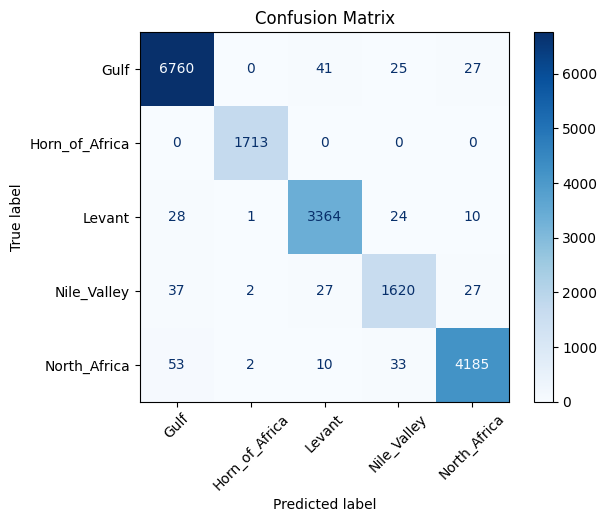

In [49]:
labels = le.classes_

plt.figure(figsize=(10,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(cmap='Blues', xticks_rotation=45)

plt.title("Confusion Matrix")

plt.show()

In [53]:
#let's create a demo to see if it's actually work !
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(100000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

In [54]:
samples = balanced_df.sample(5, random_state=42)[['#2_tweet', 'Region']]

demo_texts = samples['#2_tweet'].tolist()

In [55]:
inputs = tokenizer(
    demo_texts,
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors="pt"
)

inputs = {k: v.to(device) for k, v in inputs.items()}

In [56]:
model.eval()

with torch.no_grad():
    outputs = model(**inputs)

predictions = torch.argmax(outputs.logits, dim=1)

predicted_labels = le.inverse_transform(predictions.cpu().numpy())

In [57]:
for i, text in enumerate(demo_texts):

    print("=" * 100)

    print("Tweet:")
    print(text)

    print("\nActual Region:")
    print(samples.iloc[i]['Region'])

    print("\nPredicted Region:")
    print(predicted_labels[i])

    print("=" * 100)

Tweet:
طيب من لله

Actual Region:
Levant

Predicted Region:
Levant
Tweet:
بسم الله عليك انطمي

Actual Region:
Nile_Valley

Predicted Region:
Nile_Valley
Tweet:
أنت الي ينـقال عنك أجمل حظ .

Actual Region:
Gulf

Predicted Region:
Gulf
Tweet:
كلنا ابتلينا بشخص لو شنو يسوي ما نقدر نكرهه.

Actual Region:
Gulf

Predicted Region:
Gulf
Tweet:
نستناو خمسة سنين أخرين بالكشي نجيو لوالا

Actual Region:
North_Africa

Predicted Region:
North_Africa


In [58]:
#now after we trained on each region let's train for countries!
regions = balanced_df["Region"].unique()

print(regions)

['Nile_Valley' 'Horn_of_Africa' 'Gulf' 'North_Africa' 'Levant']


In [59]:
regional_models = {}
regional_encoders = {}
regional_trainers = {}

In [60]:
for region in regions:

    print("=" * 100)
    print("Training Region:", region)

    region_df = balanced_df[
        balanced_df["Region"] == region
    ].copy()

    encoder = LabelEncoder()

    region_df["country_label"] = encoder.fit_transform(
        region_df["#3_country_label"]
    )

    train_texts, val_texts, train_labels, val_labels = train_test_split(
        region_df["#2_tweet"].tolist(),
        region_df["country_label"].tolist(),
        test_size=0.2,
        random_state=42,
        stratify=region_df["country_label"]
    )

    train_encodings = tokenizer(
        train_texts,
        truncation=True,
        padding=True,
        max_length=128
    )

    val_encodings = tokenizer(
        val_texts,
        truncation=True,
        padding=True,
        max_length=128
    )

    train_dataset = NadiDataset(
        train_encodings,
        train_labels
    )

    val_dataset = NadiDataset(
        val_encodings,
        val_labels
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(encoder.classes_)
    )

    model.to(device)

    training_args = TrainingArguments(
        output_dir=f"./{region}_results",
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=2,
        logging_steps=100
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics
    )

    trainer.train()

    results = trainer.evaluate()

    print(results)

    regional_models[region] = model
    regional_encoders[region] = encoder
    regional_trainers[region] = trainer

Training Region: Nile_Valley


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.018826,0.013772,0.998250,0.998250
2,0.000121,0.020882,0.997083,0.997083


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.000121,0.020882,2,0.997083,0.997083


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.195808,0.087818,0.980449,0.980379
2,0.019160,0.030085,0.994164,0.994157


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.019160,0.030085,2,0.994164,0.994157


{'eval_loss': 0.03008546121418476, 'eval_accuracy': 0.9941639918295886, 'eval_f1': 0.9941571319702849}


In [62]:
def get_predictions(model, texts, batch_size=16):

    model.eval()
    preds = []

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):

            batch = texts[i:i+batch_size]

            inputs = tokenizer(
                batch,
                truncation=True,
                padding=True,
                max_length=128,
                return_tensors="pt"
            )

            inputs = {k: v.to(device) for k, v in inputs.items()}

            outputs = model(**inputs)

            batch_preds = torch.argmax(outputs.logits, dim=1)

            preds.extend(batch_preds.cpu().numpy())

    return np.array(preds)

CONFUSION MATRIX: Nile_Valley


<Figure size 1000x800 with 0 Axes>

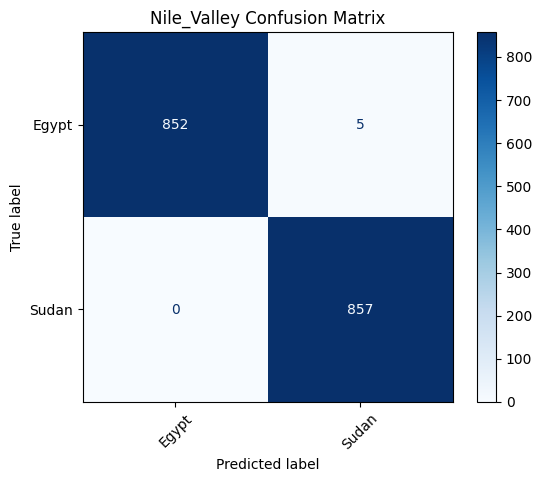

CONFUSION MATRIX: Horn_of_Africa


<Figure size 1000x800 with 0 Axes>

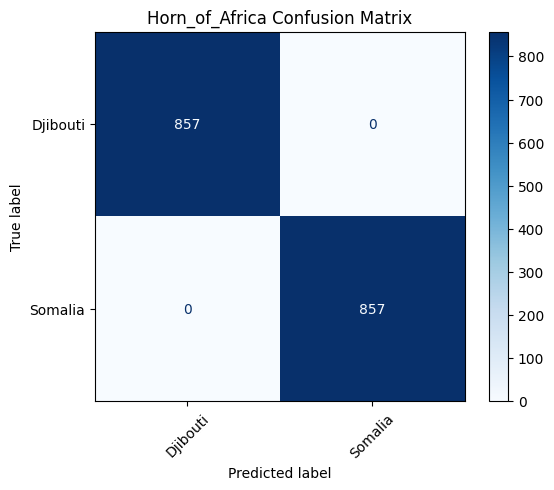

CONFUSION MATRIX: Gulf


<Figure size 1000x800 with 0 Axes>

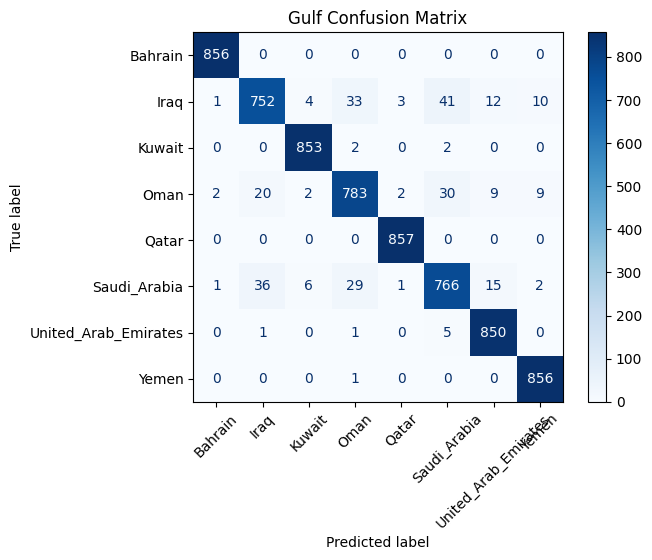

CONFUSION MATRIX: North_Africa


<Figure size 1000x800 with 0 Axes>

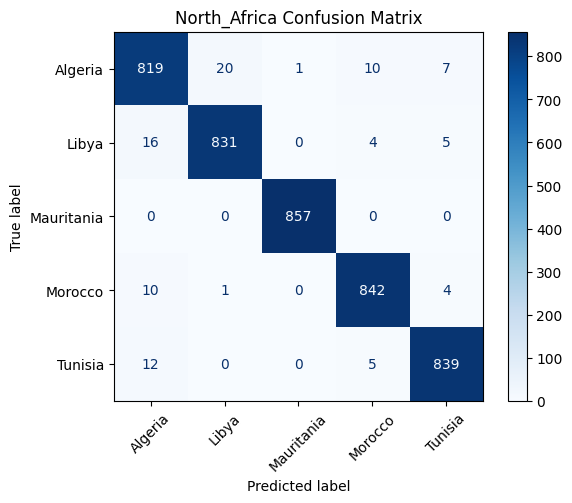

CONFUSION MATRIX: Levant


<Figure size 1000x800 with 0 Axes>

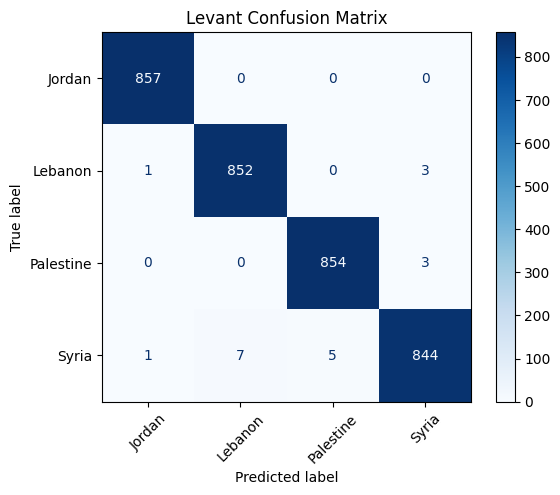

In [63]:
for region in regions:

    print("=" * 80)
    print("CONFUSION MATRIX:", region)

    region_df = balanced_df[balanced_df["Region"] == region].copy()

    encoder = regional_encoders[region]

    region_df["country_label"] = encoder.transform(region_df["#3_country_label"])

    _, val_texts, _, val_labels = train_test_split(
        region_df["#2_tweet"].tolist(),
        region_df["country_label"].tolist(),
        test_size=0.2,
        random_state=42,
        stratify=region_df["country_label"]
    )

    model = regional_models[region]

    y_pred = get_predictions(model, val_texts, batch_size=16)

    cm = confusion_matrix(val_labels, y_pred)

    plt.figure(figsize=(10, 8))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=encoder.classes_
    )

    disp.plot(cmap="Blues", xticks_rotation=45)

    plt.title(f"{region} Confusion Matrix")

    plt.show()

In [64]:
for region in regions:

    print("\n")
    print("=" * 100)
    print("DEMO FOR:", region)

    region_df = balanced_df[
        balanced_df["Region"] == region
    ]

    sample = region_df.sample(1)

    text = sample.iloc[0]["#2_tweet"]

    actual_country = sample.iloc[0]["#3_country_label"]

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    model = regional_models[region]

    model.eval()

    with torch.no_grad():
        outputs = model(**inputs)

    prediction = torch.argmax(
        outputs.logits,
        dim=1
    )

    predicted_country = regional_encoders[
        region
    ].inverse_transform(
        prediction.cpu().numpy()
    )[0]

    print("Tweet:")
    print(text)

    print("\nActual Country:")
    print(actual_country)

    print("\nPredicted Country:")
    print(predicted_country)



DEMO FOR: Nile_Valley
Tweet:
اة كفاية عليكي النت دة انتي مجروحه اوي يابنتي معلش

Actual Country:
Egypt

Predicted Country:
Egypt


DEMO FOR: Horn_of_Africa
Tweet:
كل صوره مش واضح #اليسا مافي صوره واضحه  URL  …

Actual Country:
Djibouti

Predicted Country:
Djibouti


DEMO FOR: Gulf
Tweet:
لاقين بطل ماي بالحوض ليلحين محد قادر يطلعه

Actual Country:
Kuwait

Predicted Country:
Kuwait


DEMO FOR: North_Africa
Tweet:
مؤسسة سمسس وا أجكك تنظم  URL 

Actual Country:
Morocco

Predicted Country:
Morocco


DEMO FOR: Levant
Tweet:
الفيزيا جت خدت المجموع وطارت حرفيا

Actual Country:
Lebanon

Predicted Country:
Lebanon
